# Road Condition Experiments (CNN Baselines)

This notebook mirrors the *experiment runner → results table → plots* style of `AttentionPlacement_CNN.ipynb`, but uses your road-condition dataset.

**Data contract (matches `preprocess.py` and `dummy_model.py`):**
- Dataset root folder: `UDOT WINTER ROAD CONDITIONS.v1i.folder`
- CSV index: `{DATA_ROOT}/dataset_index.csv` with columns `image_id, split, label`
- Image paths: `{DATA_ROOT}/{split}/{label}/{image_id}`
- Images are expected to be RGB and resized to **224×224** (recommended: run `preprocess.py` first)

**Default run:** trains a few basic CNN baselines.

**Attention placement grid search:** included later but disabled by default.

In [1]:
import os
import time
import random

import numpy as np
import pandas as pd

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from road_data import DatasetPaths, make_dataloaders
from road_models import (
    AttentionConfig,
    LeNet224_Attn,
    SmallAlexNet224_Attn,
    torchvision_resnet18,
)
from train_utils import FitConfig, train_and_record

sns.set_theme()

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)

# Reproducibility (mirrors AttentionPlacement_CNN.ipynb)
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Device in use: cuda


In [3]:
# Paths / config (kept consistent with existing scripts)
paths = DatasetPaths(data_root="UDOT WINTER ROAD CONDITIONS.v1i.folder")
DATA_ROOT = paths.data_root
CSV_PATH = paths.csv_path

BATCH_SIZE = 32
NUM_WORKERS = 0  # keep 0 for Windows stability; increase if you want

fit_cfg = FitConfig(
    epochs=20,
    lr=1e-3,
    patience=5,
)

print("DATA_ROOT:", DATA_ROOT)
print("CSV_PATH:", CSV_PATH)

DATA_ROOT: UDOT WINTER ROAD CONDITIONS.v1i.folder
CSV_PATH: UDOT WINTER ROAD CONDITIONS.v1i.folder/dataset_index.csv


In [4]:
# Data loaders
# Note: make_dataloaders uses minimal transforms: Resize((224,224)) + ToTensor()

try:
    train_dl, val_dl, test_dl, label_to_idx = make_dataloaders(
        data_root=DATA_ROOT,
        csv_path=CSV_PATH,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        ensure_224=True,
        seed=SEED,
    )
except FileNotFoundError as e:
    raise FileNotFoundError(
        "Dataset images were not found on disk.\n"
        "Expected layout: 'UDOT WINTER ROAD CONDITIONS.v1i.folder/{split}/{label}/{image_id}'.\n"
        "If you have the dataset locally, place it at the repo root with that exact folder name,\n"
        "then (optionally) run preprocess.py to resize images to 224x224,\n"
        "and ensure dataset_index.csv exists (dummy_model.py can rebuild it).\n\n"
        f"Original error: {e}"
    )

idx_to_label = {v: k for k, v in label_to_idx.items()}
num_classes = len(label_to_idx)

print("Classes:", num_classes)
print("Label mapping:", label_to_idx)
print()
print("Train samples:", len(train_dl.dataset))
print("Valid samples:", len(val_dl.dataset))
print("Test samples:", len(test_dl.dataset))

# Quick batch shape check
x, y = next(iter(train_dl))
print("Batch image tensor:", tuple(x.shape))
print("Batch label tensor:", tuple(y.shape), "min=", int(y.min()), "max=", int(y.max()))

Classes: 4
Label mapping: {'Clear': 0, 'Slush': 1, 'Snow': 2, 'Wet': 3}

Train samples: 4363
Valid samples: 1261
Test samples: 621
Batch image tensor: (32, 3, 224, 224)
Batch label tensor: (32,) min= 0 max= 3


In [5]:
# --- Baseline models (no attention) ---
# These are adapted to 224x224 via adaptive pooling.

baselines = [
    ("LeNet224", LeNet224_Attn(num_classes=num_classes, attn=AttentionConfig(attention_type="none", position="none"))),
    ("SmallAlexNet224", SmallAlexNet224_Attn(num_classes=num_classes, attn=AttentionConfig(attention_type="none", position="none"))),
    ("ResNet18", torchvision_resnet18(num_classes=num_classes)),
]

In [6]:
results = []

for model_name, model in baselines:
    print(f"\n[{model_name}]")
    r = train_and_record(
        model_name=model_name,
        model=model,
        train_dl=train_dl,
        val_dl=val_dl,
        test_dl=test_dl,
        device=device,
        fit_config=fit_cfg,
        metadata={"attention_type": "none", "position": "none"},
    )
    results.append(r)

print("\nDone.")


[LeNet224]
Epoch [1/20] | Train 1.1248 | Val 1.0273 | ValAcc 0.5902 | LR 1.00e-03
Epoch [2/20] | Train 1.0243 | Val 0.9627 | ValAcc 0.5937 | LR 1.00e-03
Epoch [3/20] | Train 0.9690 | Val 0.9386 | ValAcc 0.5638 | LR 1.00e-03
Epoch [4/20] | Train 0.9432 | Val 0.9103 | ValAcc 0.5648 | LR 1.00e-03
Epoch [5/20] | Train 0.9202 | Val 0.8926 | ValAcc 0.5930 | LR 1.00e-03
Epoch [6/20] | Train 0.9040 | Val 0.8700 | ValAcc 0.5807 | LR 1.00e-03
Epoch [7/20] | Train 0.8906 | Val 0.8741 | ValAcc 0.5807 | LR 1.00e-03
Epoch [8/20] | Train 0.8841 | Val 0.8600 | ValAcc 0.5755 | LR 1.00e-03
Epoch [9/20] | Train 0.8776 | Val 0.8574 | ValAcc 0.6123 | LR 1.00e-03
Epoch [10/20] | Train 0.8744 | Val 0.8394 | ValAcc 0.6181 | LR 1.00e-03
Epoch [11/20] | Train 0.8677 | Val 0.8471 | ValAcc 0.5811 | LR 1.00e-03
Epoch [12/20] | Train 0.8655 | Val 0.8251 | ValAcc 0.5936 | LR 1.00e-03
Epoch [13/20] | Train 0.8489 | Val 0.8195 | ValAcc 0.6282 | LR 1.00e-03
Epoch [14/20] | Train 0.8442 | Val 0.8197 | ValAcc 0.6474 | L

,model,best_val_acc,best_val_loss,test_acc,test_loss,train_time_min,avg_epoch_s,images_per_sec,attention_type,position
0,ResNet18,0.862951,0.385137,0.869896,0.408839,2.230740,6.692219,651.951179,none,none
1,SmallAlexNet224,0.829358,0.433352,0.851806,0.377453,2.658649,7.975946,547.019762,none,none
2,LeNet224,0.698351,0.734561,0.722847,0.684792,1.844620,5.533861,788.418840,none,none


Saved: road_condition_results.csv


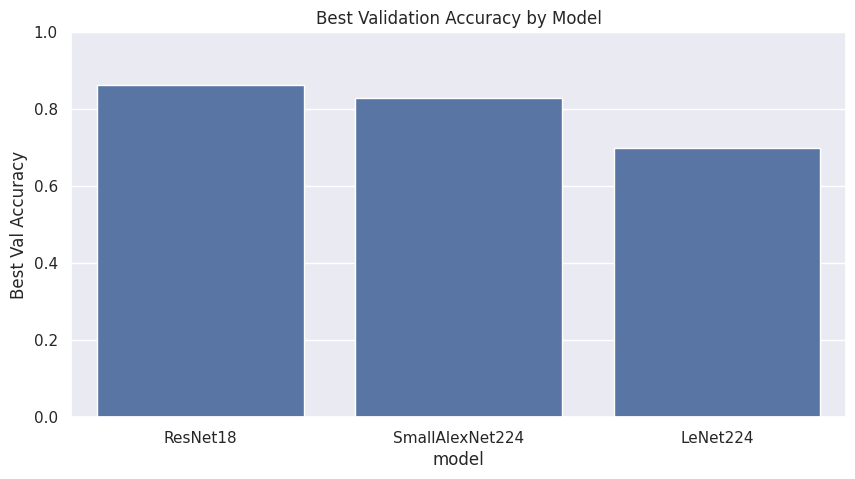

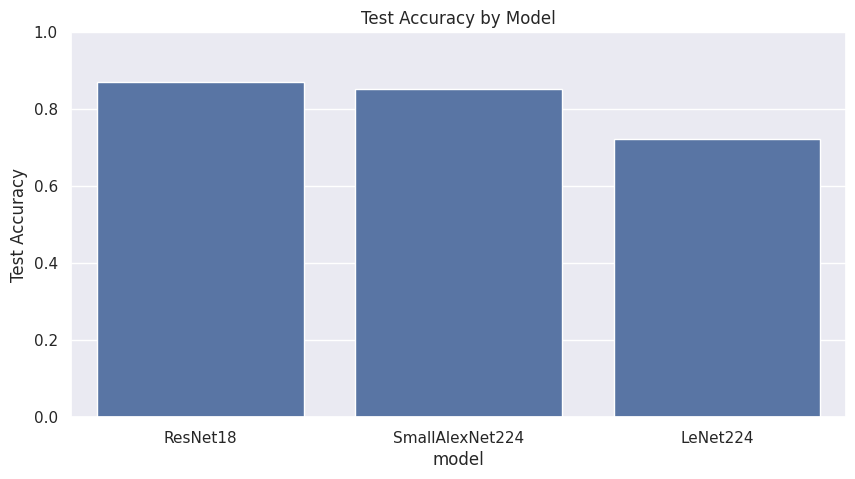

In [7]:
# Results table + plots

df = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in results])
df = df.sort_values("best_val_acc", ascending=False).reset_index(drop=True)

out_csv = "road_condition_results.csv"
df.to_csv(out_csv, index=False)

display(df)
print("Saved:", out_csv)

plt.figure(figsize=(10, 5))
sns.barplot(df, x="model", y="best_val_acc")
plt.title("Best Validation Accuracy by Model")
plt.ylabel("Best Val Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(df, x="model", y="test_acc")
plt.title("Test Accuracy by Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()

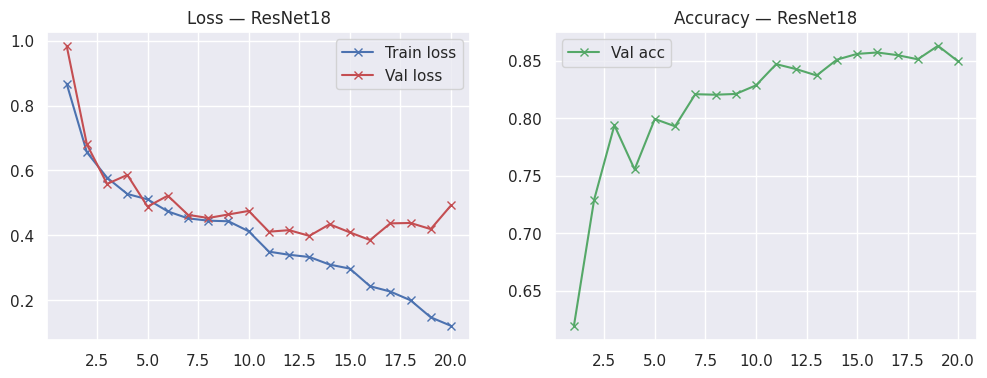

In [8]:
def plot_training_curves(history, title="Training"):
    epochs = [h["epoch"] for h in history]
    tl = [h["train_loss"] for h in history]
    vl = [h["val_loss"] for h in history]
    va = [h["val_acc"] for h in history]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, tl, "-bx", label="Train loss")
    plt.plot(epochs, vl, "-rx", label="Val loss")
    plt.legend(); plt.title(f"Loss — {title}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, va, "-gx", label="Val acc")
    plt.legend(); plt.title(f"Accuracy — {title}")
    plt.show()

# Example: plot the best run
best_row = df.iloc[0]
best = next(r for r in results if r["model"] == best_row["model"])
plot_training_curves(best["history"], title=f"{best_row['model']}")

## Attention placement grid (disabled for now)

This section mirrors the grid-search idea from `AttentionPlacement_CNN.ipynb`, but it is **disabled by default**. To enable, change `if False:` to `if True:` and consider reducing epochs first.

In [9]:
# Disabled by default

attn_types = ["CBAM"]
positions = ["early", "mid", "late", "all"]

grid_results = []

for attn_type in attn_types:
    for pos in positions:
        print(f"\n[LeNet224 + {attn_type} at {pos}]")
        model = LeNet224_Attn(
            num_classes=num_classes,
            attn=AttentionConfig(attention_type=attn_type, position=pos),
        )
        r = train_and_record(
            model_name="LeNet224",
            model=model,
            train_dl=train_dl,
            val_dl=val_dl,
            test_dl=test_dl,
            device=device,
            fit_config=fit_cfg,
            metadata={"attention_type": attn_type, "position": pos},
        )
        grid_results.append(r)

# Merge grid results into the main results list if desired
# results.extend(grid_results)
# (Rebuild df/plots after extending)